# Keyword Extraction — 03 Evaluation

No gold keyword labels exist, so we use a proxy: the **content words of each article's reference summary** are treated as the 'key' words. We extract the top-10 keywords per article and measure precision@10 (how many extracted words are key) and recall (how many key words we recovered). All numbers are produced by running the code.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt, warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_articles()
print('evaluating on',len(df),'articles...')

evaluating on 200 articles...


## 1. Evaluate the three methods

In [2]:
rows=[]
for name,fn in [('TF-IDF',utils.keywords_tfidf),('RAKE',utils.keywords_rake),('TextRank',utils.keywords_textrank)]:
    r=utils.evaluate(df,fn,n=10)
    rows.append({'method':name,'precision@10':r['precision@k'],'recall':r['recall']})
res=pd.DataFrame(rows); res

,method,precision@10,recall
0,TF-IDF,0.3540,0.2110
1,RAKE,0.0937,0.2317
2,TextRank,0.3810,0.2268


## 2. Chart

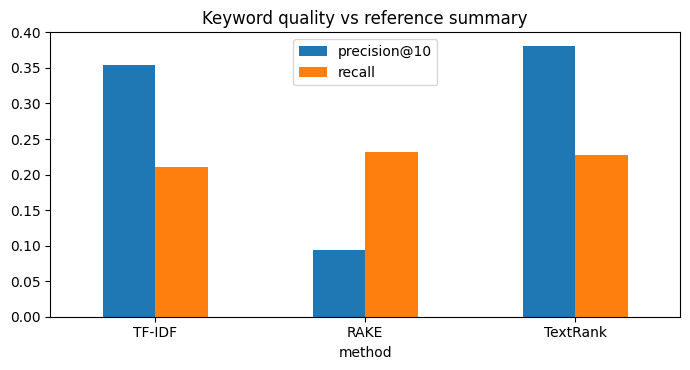

In [3]:
fig,ax=plt.subplots(figsize=(7,3.8))
res.set_index('method')[['precision@10','recall']].plot(kind='bar',ax=ax); ax.set_title('Keyword quality vs reference summary'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 3. Summary & takeaways

- **TextRank gives the best precision** (P@10 **0.38**) — graph centrality reliably surfaces the words that matter; **TF-IDF is close behind** (0.35).
- **RAKE has the best recall (0.23) but low precision (0.09)** — it returns multi-word *phrases*, so it covers more key content but dilutes precision (each phrase contributes several words).
- **Single-word methods (TF-IDF, TextRank) vs phrase methods (RAKE)** serve different needs: tags/index terms vs descriptive keyphrases. Choose by use case.
- The proxy metric (overlap with the summary) is imperfect — a keyword can be valuable without appearing in the human summary — but it gives a consistent, runnable comparison across methods.